## Theta Initialization Ablation Study

Compares initialization strategies from `weight_study.py` on a fixed directory of CNF instances.
Metrics recorded per method × instance:
- **Satisfaction rate** (% clauses satisfied)
- **Peak memory usage** (MB, via `tracemalloc`)
- **Total runtime** (training + decoding, seconds)

In [1]:
%load_ext autoreload
%autoreload 2

import argparse
import csv
import time
import tracemalloc
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from helpers import load_cnf_file, count_satisfied_batch
from Maxsat_dNN import MaxsatdNN
from weight_study import initialize_weights

In [13]:
# ----------------------------------------------------------------------
# Configuration — edit these before running
# ----------------------------------------------------------------------
CNF_DIR    = Path("instances/uf100.430.1000")
CNF_LIMIT  = 1000          # number of instances to use (None = all)
OUTPUT_DIR = Path("init_ablation_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")
DTYPE  = torch.float32

INIT_METHODS = [
    "random_uniform",
    "literal_frequency",
    "jw_heuristic",
    "clause_degree",
    "polarity_aware",
]
FIXED_PARAMS = dict(
    epochs         = 1000,
    lr             = 0.09727746954141563,
    batch_size     = 47,
    grad_clip      = 1.0,
    eta_min        = 0.0,
    patience       = 20,
    weight_decay   = 5.210905999973664e-05,
    random_noise   = 0.05,   # per-column noise added on top of base init
    warmup_epochs  = 10,
    restart_period = 70,
    restart_samples= 50,
)

cnf_files = sorted(CNF_DIR.glob("*.cnf"))
if CNF_LIMIT:
    cnf_files = cnf_files[:CNF_LIMIT]
print(f"Instances: {len(cnf_files)}  |  Methods: {INIT_METHODS}")

Instances: 1000  |  Methods: ['random_uniform', 'literal_frequency', 'jw_heuristic', 'clause_degree', 'polarity_aware']


In [16]:
from helpers import refine_with_bruteforce
def train_with_init(cnf, method: str, params: dict, device, dtype) -> dict:
    """
    Train MaxsatdNN with a specific theta initialization.
    Returns a result dict including satisfaction rate, peak memory (MB), and runtimes.
    """
    B     = params["batch_size"]
    n     = cnf.nv
    noise = params["random_noise"]

    tracemalloc.start()
    t_total_start = time.perf_counter()

    # Build solver with default random init, then overwrite theta_var
    solver = MaxsatdNN(cnf, batch_size=B, random_noise=noise).to(device=device, dtype=dtype)

    with torch.no_grad():
        # Compute the base 1-D init vector for this method
        base = initialize_weights(method, cnf, n).data.float().clamp(0.0, 1.0)
        if B > 1:
            cols = [
                (base + torch.rand(n) * noise).clamp(0.0, 1.0)
                for _ in range(B)
            ]
            solver.theta_var.weight.data = torch.stack(cols, dim=1).to(dtype)
        else:
            solver.theta_var.weight.data = base.to(dtype)

        # Freeze clause weights for unweighted MaxSAT
        solver.theta_clause.weight.fill_(1.0)

    optimizer = torch.optim.AdamW(
        [solver.theta_var.weight], lr=params["lr"], weight_decay=params["weight_decay"]
    )
    warmup_sched = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=params["warmup_epochs"]
    )
    cosine_sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=params["restart_period"], T_mult=1, eta_min=params["eta_min"]
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[params["warmup_epochs"]]
    )

    best_obj   = float("inf")
    no_improve = 0
    t_train_start = time.perf_counter()

    for epoch in range(params["epochs"]):
        optimizer.zero_grad()
        obj = solver()
        (obj.sum() if B > 1 else obj).backward()
        torch.nn.utils.clip_grad_norm_([solver.theta_var.weight], params["grad_clip"])
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            solver.theta_var.weight.data.clamp_(0.0, 1.0)
            col_min = obj.min().item() if B > 1 else obj.item()

            if col_min < best_obj - 1e-6:
                best_obj   = col_min
                no_improve = 0
            else:
                no_improve += 1

            if params["patience"] > 0 and no_improve >= params["patience"]:
                break

    train_time = time.perf_counter() - t_train_start

    # Decoding: randomised rounding + greedy hill-climb
    t_decode_start = time.perf_counter()
    num_satisfied, best_bool = count_satisfied_batch(
        cnf, solver.theta_var.weight,
        n_samples_per_restart=params["restart_samples"],
        return_assignment=True,
    )
    decode_time = time.perf_counter() - t_decode_start
    # ------------------------------------------------------------
    # Step 2: post‑hoc freeze + brute‑force on uncertain variables 
    # ------------------------------------------------------------
    confidence_threshold = params.get("confidence_threshold", 0.9)
    max_free_vars        = params.get("max_free_vars", 10)
    brute_start = time.perf_counter()
    best_bool_refined, satisfied_refined = refine_with_bruteforce(
        best_bool, solver.theta_var.weight.detach(), cnf,
        confidence_threshold=confidence_threshold,
        max_free_vars=max_free_vars
    )
    brute_time = time.perf_counter() - brute_start

    # Use the refined assignment if it improves satisfaction
    if satisfied_refined > num_satisfied:
        num_satisfied = satisfied_refined
        best_bool     = best_bool_refined

    total_time = time.perf_counter() - t_total_start

    _, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mb = peak_bytes / (1024 ** 2)

    total_clauses = len(cnf.clauses)
    sat_rate      = num_satisfied / total_clauses if total_clauses else 0.0

    return {
        "num_satisfied"    : int(num_satisfied),
        "total_clauses"    : total_clauses,
        "satisfaction_rate": round(sat_rate, 6),
        "fully_satisfied"  : num_satisfied == total_clauses,
        "train_time_s"     : round(train_time, 3),
        "decode_time_s"    : round(decode_time, 3),
        "brute_time_s"     : round(brute_time, 3),
        "total_time_s"     : round(total_time, 3),
        "peak_memory_mb"   : round(peak_mb, 3),
        "best_objective"   : best_obj,
        "epochs_run"       : epoch + 1,
    }

In [20]:
import gc
# ----------------------------------------------------------------------
# Run the ablation
# ----------------------------------------------------------------------
all_rows = []

def force_gc():
    gc.collect()
    gc.collect()
    gc.collect()
for file_idx, cnf_path in enumerate(cnf_files):
    force_gc()
    cnf  = load_cnf_file(str(cnf_path))
    name = cnf_path.stem
    print(f"\n[{file_idx+1}/{len(cnf_files)}] {name}  ({cnf.nv} vars, {len(cnf.clauses)} clauses)")
    force_gc()
    for method in INIT_METHODS:
        force_gc()
        result = train_with_init(cnf, method, FIXED_PARAMS, DEVICE, DTYPE)
        row = {"instance": name, "init_method": method, **result}
        all_rows.append(row)
        print(
            f"  {method:<20s}  sat={100*result['satisfaction_rate']:.1f}%  "
            f"time={result['total_time_s']:.1f}s  mem={result['peak_memory_mb']:.1f}MB"
        )

# Save full results
results_path = OUTPUT_DIR / "ablation_results.csv"
df = pd.DataFrame(all_rows)
df.to_csv(results_path, index=False)
print(f"\nResults saved to {results_path}")


[1/1000] uf100-01  (100 vars, 430 clauses)
  random_uniform        sat=98.4%  time=0.3s  mem=0.8MB
  literal_frequency     sat=98.1%  time=0.3s  mem=0.1MB
  jw_heuristic          sat=97.0%  time=0.3s  mem=0.1MB
  clause_degree         sat=98.1%  time=0.3s  mem=0.1MB
  polarity_aware        sat=97.2%  time=0.3s  mem=0.1MB

[2/1000] uf100-010  (100 vars, 430 clauses)
  random_uniform        sat=98.6%  time=0.3s  mem=0.1MB
  literal_frequency     sat=98.1%  time=0.3s  mem=0.1MB
  jw_heuristic          sat=97.7%  time=0.3s  mem=0.1MB
  clause_degree         sat=98.1%  time=0.3s  mem=0.1MB
  polarity_aware        sat=98.1%  time=0.3s  mem=0.1MB

[3/1000] uf100-0100  (100 vars, 430 clauses)
  random_uniform        sat=99.1%  time=0.4s  mem=0.1MB
  literal_frequency     sat=98.4%  time=0.3s  mem=0.1MB
  jw_heuristic          sat=97.7%  time=0.3s  mem=0.1MB
  clause_degree         sat=98.1%  time=0.4s  mem=0.1MB
  polarity_aware        sat=97.7%  time=0.3s  mem=0.1MB

[4/1000] uf100-01000  (1

In [26]:
# ----------------------------------------------------------------------
# Summary statistics per initialization method
# ----------------------------------------------------------------------
df = pd.read_csv(OUTPUT_DIR / "ablation_results.csv")

summary = df.groupby("init_method").agg(
    avg_sat_rate  =("satisfaction_rate", "mean"),
    pct_fully_sat =("fully_satisfied",   "mean"),
    avg_time_s    =("total_time_s",      "mean"),
    avg_memory_mb =("peak_memory_mb",    "mean"),
    avg_epochs    =("epochs_run",        "mean"),
).reset_index()

summary["avg_sat_pct"]   = (summary["avg_sat_rate"] * 100).round(3)
#summary["pct_fully_sat"] = (summary["pct_fully_sat"] * 100).round(1)
summary = summary.sort_values("avg_sat_pct", ascending=False)

print(summary[[
    "init_method", "avg_sat_pct",
    "avg_time_s", "avg_memory_mb", "avg_epochs"
]].to_string(index=False))

      init_method  avg_sat_pct  avg_time_s  avg_memory_mb  avg_epochs
literal_frequency       97.849    0.323546       0.132329     102.363
    clause_degree       97.837    0.328995       0.131384     102.710
     jw_heuristic       97.837    0.323276       0.131717     102.000
   polarity_aware       97.780    0.320682       0.131340     101.592
   random_uniform       97.771    0.326447       0.131166     102.481


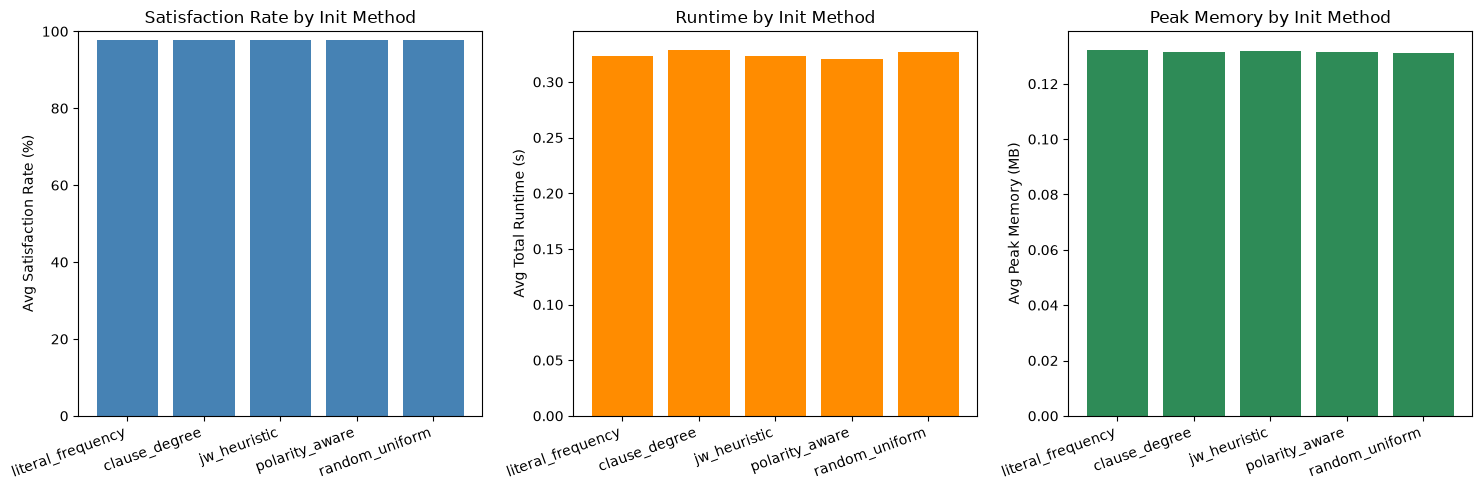

Plot saved to init_ablation_results/ablation_comparison.png


In [22]:
# ----------------------------------------------------------------------
# Plots
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
methods = summary["init_method"].tolist()
x       = range(len(methods))

axes[0].bar(x, summary["avg_sat_pct"], color="steelblue")
axes[0].set_xticks(x); axes[0].set_xticklabels(methods, rotation=20, ha="right")
axes[0].set_ylabel("Avg Satisfaction Rate (%)")
axes[0].set_title("Satisfaction Rate by Init Method")
axes[0].set_ylim(0, 100)

axes[1].bar(x, summary["avg_time_s"], color="darkorange")
axes[1].set_xticks(x); axes[1].set_xticklabels(methods, rotation=20, ha="right")
axes[1].set_ylabel("Avg Total Runtime (s)")
axes[1].set_title("Runtime by Init Method")

axes[2].bar(x, summary["avg_memory_mb"], color="seagreen")
axes[2].set_xticks(x); axes[2].set_xticklabels(methods, rotation=20, ha="right")
axes[2].set_ylabel("Avg Peak Memory (MB)")
axes[2].set_title("Peak Memory by Init Method")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ablation_comparison.png", dpi=150)
plt.show()
print(f"Plot saved to {OUTPUT_DIR / 'ablation_comparison.png'}")